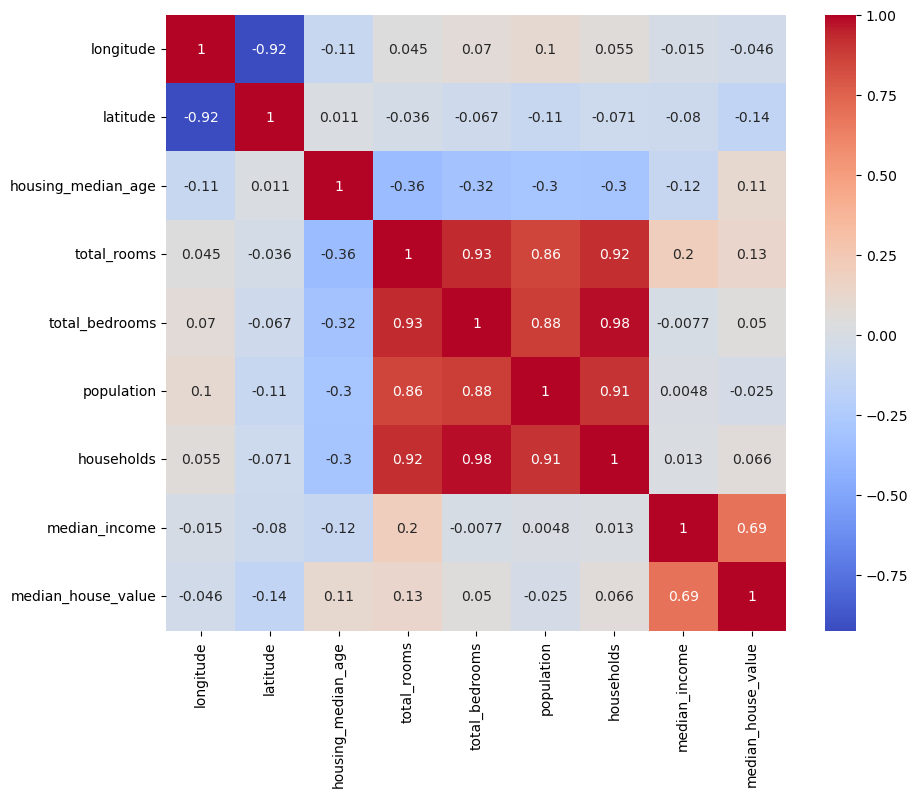

r2_score: 0.6393330884055006
root_mean_squared_error 68747.447887747
Best Params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 50}


In [2]:
import pandas as pd

data=pd.read_csv(r"housing.csv")
data
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=True)
plt.show()

data=pd.DataFrame(data)
x=data.drop(columns=["median_house_value"])
y=data["median_house_value"]

x = pd.get_dummies(x, drop_first=True)
x

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)
x

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.tree import DecisionTreeRegressor
TreeReg=DecisionTreeRegressor()
TreeReg.fit(x_train,y_train)
y_pred=TreeReg.predict(x_test)

from sklearn.metrics import r2_score,root_mean_squared_error
print("r2_score:",r2_score(y_test, y_pred) )
print("root_mean_squared_error",root_mean_squared_error(y_test,y_pred))




# decision tree classifier with pre-pruning and hyper parameter tuning
param = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'splitter' : ['best', 'random'],
    'max_depth' : [1, 2, 3, 4, 5],
    'max_features' : ['auto', 'sqrt', 'log2']
}

param

from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeRegressor
tree_model=DecisionTreeRegressor()


from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}



grid = GridSearchCV(
    tree_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(x_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)


y_pred1 = grid.predict(x_test)
y_pred1
tree_model.fit(x_train,y_train)
y_pred=tree_model.predict(x_test)



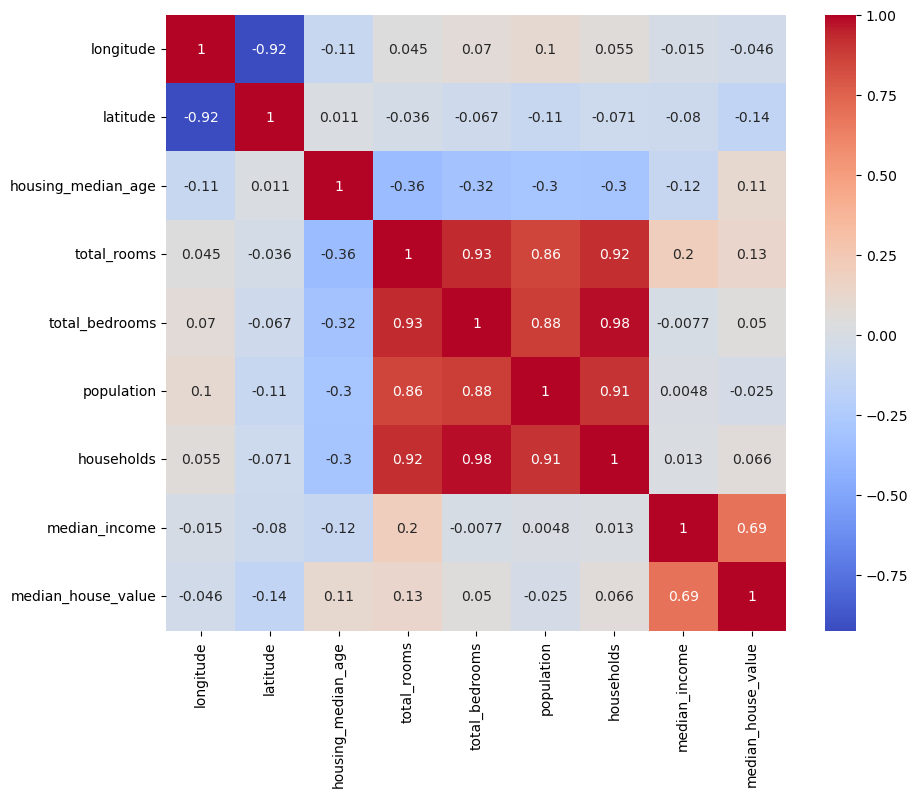

Best Params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 50}
R²: 0.7448227788938763
RMSE: 57826.16376520474


Exception ignored in: <function ResourceTracker.__del__ at 0x1068c1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111db1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107955c60>
Traceback (most recent call last

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load data
data = pd.read_csv("housing.csv")

# Correlation heatmap
numeric_data = data.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=True)
plt.show()

# Prepare features and target
x = pd.get_dummies(data.drop(columns=["median_house_value"]), drop_first=True)
y = data["median_house_value"]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Decision Tree Regressor with GridSearch
tree_model = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}

grid = GridSearchCV(tree_model, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=1)
grid.fit(x_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

# Predict and evaluate
y_pred = best_model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
